In [2]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pickle
from tqdm.notebook import tqdm
from ci import *
from val_test import val_test
from print_results import *

import warnings
warnings.filterwarnings("ignore")
tslen = 200

## Loading Data

In [3]:
def loading():
    with open('unaligned_betas.pkl','rb') as f:
        betas = pickle.load(f)
    with open('euclidean_mean.pkl','rb') as f:
        mu = pickle.load(f)
    return betas, mu

K = 32
M = 3
T = tslen
R = 38
nsamples = 155

betas_org, mu_all_t = loading()
betas = betas_org.transpose(1, 2, 3, 0)
betas_flat = betas.reshape((K*M*T, nsamples))
print(betas.shape, betas_flat.shape)

(32, 3, 200, 155) (19200, 155)


## Functional PCA and Skeleton Video

In [4]:
%matplotlib qt5

# Mean center
mean_betas = np.mean(betas_flat, axis=1, keepdims=True)
betas_flat_c = betas_flat - mean_betas

U, sigma, V_t = np.linalg.svd(betas_flat_c, full_matrices=False)
vec_reconstructed = U[:,0:R].reshape((K, M, T, R))
lambdas = (sigma**2)/(nsamples-1)

betas_hat_t = []
scales = [-2, 0, 2]

for r in range(1):
    for s_id, scale in enumerate(scales):

      sigma_scaled = float(scale * np.sqrt(lambdas[r]))
      v_r  = sigma_scaled * vec_reconstructed[:, :, :, r]
      beta_t_hat = mu_all_t + v_r
      betas_hat_t.append(beta_t_hat/1000)
    
    # p_all = plotting_betas_landmark([betas_hat_t[-3], betas_hat_t[-2], betas_hat_t[-1]], 
    #                                 colors=[(1, 0, 0), (0, 0, 0), (0, 0.5, 1)], zoom = 1)
    # video_saving(p_all, 'FPCA{}'.format(r+1))


Cumulative variance explained:
First 1 components: 0.2647 (26.47%)
First 2 components: 0.4612 (46.12%)
First 3 components: 0.6232 (62.32%)
First 4 components: 0.7507 (75.07%)
First 5 components: 0.8590 (85.90%)
First 6 components: 0.9367 (93.67%)
First 7 components: 0.9572 (95.72%)
First 8 components: 0.9690 (96.90%)
First 9 components: 0.9776 (97.76%)
First 10 components: 0.9831 (98.31%)
First 11 components: 0.9869 (98.69%)
First 12 components: 0.9900 (99.00%)
First 13 components: 0.9925 (99.25%)
First 14 components: 0.9943 (99.43%)
First 15 components: 0.9956 (99.56%)
First 16 components: 0.9962 (99.62%)
First 17 components: 0.9966 (99.66%)
First 18 components: 0.9968 (99.68%)
First 19 components: 0.9970 (99.70%)
First 20 components: 0.9972 (99.72%)
First 21 components: 0.9974 (99.74%)
First 22 components: 0.9976 (99.76%)
First 23 components: 0.9977 (99.77%)
First 24 components: 0.9978 (99.78%)
First 25 components: 0.9980 (99.80%)
First 26 components: 0.9981 (99.81%)
First 27 compon

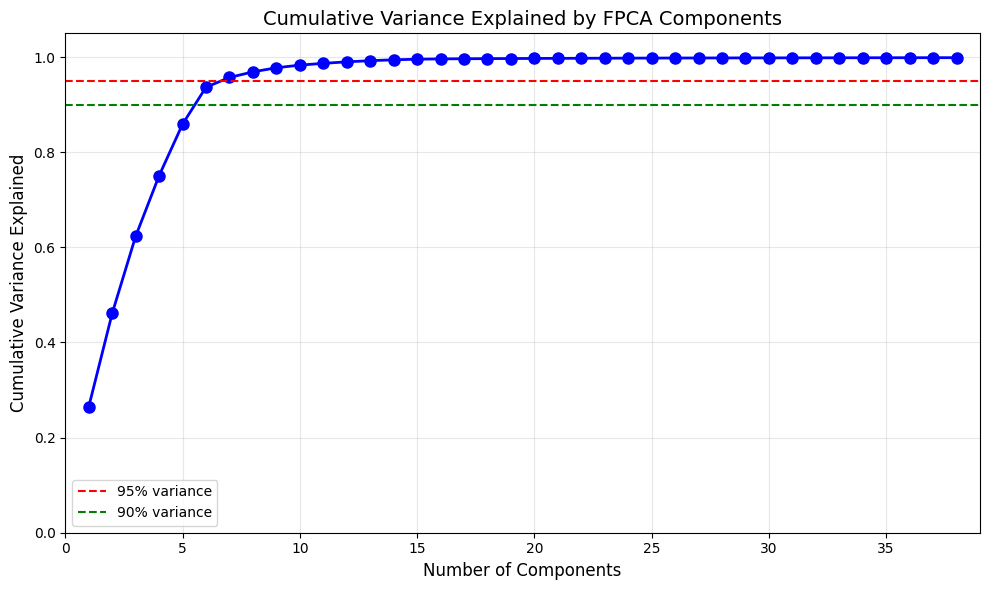


Number of components needed:
  For 90% variance: 6
  For 95% variance: 7


In [12]:
# Calculate cumulative variance explained
%matplotlib inline

# Variance explained by each component
variance_explained = lambdas / lambdas.sum()

# Cumulative variance explained
cumulative_variance = np.cumsum(variance_explained)

print("\nCumulative variance explained:")
for i in range(min(38, len(cumulative_variance))):
    print(f"First {i+1} components: {cumulative_variance[i]:.4f} ({cumulative_variance[i]*100:.2f}%)")

# Plot cumulative variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, min(39, len(cumulative_variance)+1)), cumulative_variance[:38], 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% variance')
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Variance Explained', fontsize=12)
plt.title('Cumulative Variance Explained by FPCA Components', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, min(39, len(cumulative_variance)+1))
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# Find number of components needed for 95% and 99% variance
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nNumber of components needed:")
print(f"  For 90% variance: {n_components_90}")
print(f"  For 95% variance: {n_components_95}")

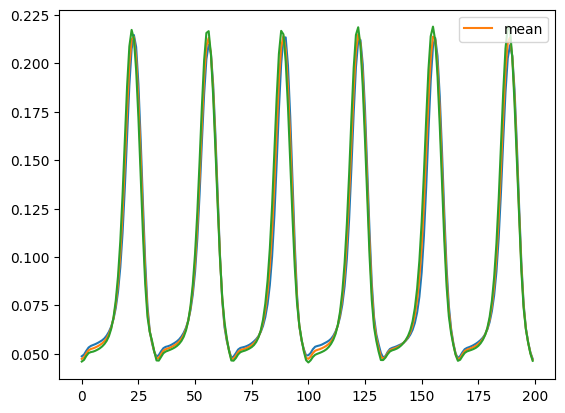

In [13]:
%matplotlib inline
plt.figure()
plt.plot(betas_hat_t[-3][30,2,:])
plt.plot(betas_hat_t[-2][30,2,:], label='mean')
plt.plot(betas_hat_t[-1][30,2,:])
plt.legend()

In [14]:
# %matplotlib inline
# print(tangent_vec_all.shape)
# plt.plot(tangent_vec_all[30,2,:,10])
# plt.figure()
# plt.plot(betas_aligned_all[10][30,2,:])

In [5]:
folder_path = "csv_r"
files = [file for file in os.listdir(folder_path)]
files = sorted(files, key=lambda x: int(x.split('_')[0][2:]))
scores_w_csv = [file.split('_')[1] for file in files]
scores = [file.split('.')[0] for file in scores_w_csv]

y = np.array(scores).astype(int)

# Participant ID for each row of X (same order as files from csv_r)
participant_ids = [re.search(r'ID(\d+)_', f).group(1) for f in files]
step = 10  # same as tcn_tangents: leave-10-participants-out per fold

print(y.shape)
print("all_participants (first 15):", participant_ids[:15])

(155,)
all_participants (first 15): ['1', '2', '3', '4', '5', '6', '7', '8', '10', '11', '13', '14', '15', '17', '18']


## Regression

In [6]:
def fpca_project(tangent_flat_train, tangent_flat_test, R=3):
    """Project train and test onto first R left singular vectors of train."""
    U, sigma, Vt = np.linalg.svd(tangent_flat_train, full_matrices=False)
    # Train: coordinates (n_train, R)
    X_train = (Vt[:R].T * sigma[:R])
    # Test: project onto U[:, :R]
    X_test = tangent_flat_test.T @ U[:, :R]
    return X_train, X_test

def mean_center(betas_flat_train, betas_flat_validation, betas_flat_test):
    # Mean center
    mean_train = np.mean(betas_flat_train, axis=1, keepdims=True)
    betas_flat_train = betas_flat_train - mean_train
    betas_flat_validation = betas_flat_validation - mean_train
    betas_flat_test = betas_flat_test - mean_train
    return betas_flat_train, betas_flat_validation, betas_flat_test

In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import xgboost as xgb
from tqdm.notebook import tqdm

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n = len(y)
n_folds = 30
R = 38

models = {
    'KNN': KNeighborsRegressor(),
    'SVM': SVR(kernel='rbf'),
    'RF': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

all_results_validation = {name: {'targets': [], 'preds': []} for name in models.keys()}
all_results_test = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models.keys()}
participant_ids = np.asarray(participant_ids)


for name, model in tqdm(models.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        betas_flat_train = betas_flat[:, train_idx]
        betas_flat_validation = betas_flat[:, validation_idx]
        betas_flat_test = betas_flat[:, test_idx]

        betas_flat_train, betas_flat_validation, betas_flat_test = mean_center(betas_flat_train, 
                                                                   betas_flat_validation, betas_flat_test)
        scaler = MinMaxScaler()
        scaler.fit(betas_flat_train.T)
        betas_flat_train = scaler.transform(betas_flat_train.T).T
        betas_flat_validation = scaler.transform(betas_flat_validation.T).T
        betas_flat_test = scaler.transform(betas_flat_test.T).T
        
        X_train, X_validation = fpca_project(betas_flat_train, betas_flat_validation, R=R)
        X_train, X_test = fpca_project(betas_flat_train, betas_flat_test, R=R)

        y_train = y[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)

        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_results_validation[name]['targets'].extend(y[validation_idx].tolist())
        all_results_validation[name]['preds'].extend(validation_preds.tolist())
        all_results_test[name]['targets'].extend(y[test_idx].tolist())
        all_results_test[name]['preds'].extend(test_preds.tolist())
        all_results_test[name]['subjects'].extend(participant_ids[test_idx].tolist())

        mae_val = mean_absolute_error(y[validation_idx], validation_preds)
        rmse_val = np.sqrt(mean_squared_error(y[validation_idx], validation_preds))
        r2_val = r2_score(y[validation_idx], validation_preds)
        # print(f"Fold {k + 1:02d} | {name} | Validation: MAE={mae_val:.3f}, RMSE={rmse_val:.3f}, R2={r2_val:.3f}")

test_results_df = print_results(all_results_validation, all_results_test, models)
test_results_df

Models:   0%|          | 0/5 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]

SVM:   0%|          | 0/30 [00:00<?, ?it/s]

RF:   0%|          | 0/30 [00:00<?, ?it/s]

XGBoost:   0%|          | 0/30 [00:00<?, ?it/s]

MLP:   0%|          | 0/30 [00:00<?, ?it/s]


=== Validation Performance (across all folds) ===
              MAE      RMSE        R2  Pearson r     Pearson p
KNN      2.872258  4.463472  0.347635   0.591352  5.436145e-16
SVM      2.836840  5.855775 -0.122829   0.718813  6.206632e-26
RF       2.244258  3.810119  0.524641   0.725852  1.208431e-26
XGBoost  2.137554  4.039303  0.465734   0.693620  1.472628e-23
MLP      5.425836  7.211031 -0.702706   0.154824  5.441090e-02

=== Test Performance (across all folds) ===


,MAE,RMSE,R2,Pearson r,Pearson p
KNN,2.872258,4.463472,0.347635,0.591352,5.436145e-16
SVM,2.836840,5.855775,-0.122829,0.718813,6.206632e-26
RF,2.244258,3.810119,0.524641,0.725852,1.208431e-26
XGBoost,2.137554,4.039303,0.465734,0.693620,1.472628e-23
MLP,5.425836,7.211031,-0.702706,0.154824,5.441090e-02


In [18]:
ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci(
    all_results_test[name]['targets'],
    all_results_test[name]['preds'],
    all_results_test[name]['subjects'])


pd.DataFrame(ci_results['KNN'])

,MAE,RMSE,R2,Pearson r
mean,2.872258,4.463472,0.347635,0.591352
ci,"[2.475, 3.268]","[3.908, 4.952]","[0.231, 0.44]","[0.493, 0.682]"


## LesionLeft Classification (same subject order as regression)

In [19]:
# Create y_lesion from LesionLeft, aligned to same participant_ids order as X
demo_df = pd.read_csv('demo_data.csv')
id_to_lesion = dict(zip(demo_df['s'].astype(int), demo_df['LesionLeft']))
y_lesion = np.array([id_to_lesion[int(pid)] for pid in participant_ids])

print("LesionLeft class distribution:", np.unique(y_lesion, return_counts=True))
print("y_lesion.shape:", y_lesion.shape)

LesionLeft class distribution: (array([0, 1, 2]), array([ 30,  14, 111]))
y_lesion.shape: (155,)


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import xgboost as xgb

# Same CV: 5 validation + 5 test (disjoint) per fold, two rounds so every subject is validated and tested once.
n_cls = len(y_lesion)
n_folds = 30
R = 38

models_clf = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(kernel='rbf'),
    'RF': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

all_val_clf = {name: {'targets': [], 'preds': []} for name in models_clf.keys()}
all_test_clf = {name: {'targets': [], 'preds': [], 'subjects': []} for name in models_clf.keys()}
participant_ids = np.asarray(participant_ids)

for name, model in tqdm(models_clf.items(), desc='Models'):
    for k in tqdm(range(n_folds), total=n_folds, desc=name, leave=False):
        validation_pids_list, test_pids_list = val_test(participant_ids, k)
        validation_pids = set(validation_pids_list)
        test_pids = set(test_pids_list)
        train_pids = set(participant_ids) - validation_pids - test_pids

        train_idx = np.array([j for j in range(n_cls) if participant_ids[j] in train_pids])
        validation_idx = np.array([j for j in range(n_cls) if participant_ids[j] in validation_pids])
        test_idx = np.array([j for j in range(n_cls) if participant_ids[j] in test_pids])
        if len(train_idx) == 0 or len(validation_idx) == 0 or len(test_idx) == 0:
            continue

        betas_flat_train = betas_flat[:, train_idx]
        betas_flat_validation = betas_flat[:, validation_idx]
        betas_flat_test = betas_flat[:, test_idx]

        betas_flat_train, betas_flat_validation, betas_flat_test = mean_center(betas_flat_train, 
                                                                   betas_flat_validation, betas_flat_test)
        
        X_train, X_validation = fpca_project(betas_flat_train, betas_flat_validation, R=R)
        X_train, X_test = fpca_project(betas_flat_train, betas_flat_test, R=R)

        y_train = y_lesion[train_idx]
        m = type(model)(**model.get_params())
        m.fit(X_train, y_train)
        validation_preds = m.predict(X_validation)
        test_preds = m.predict(X_test)
        all_val_clf[name]['targets'].extend(y_lesion[validation_idx].tolist())
        all_val_clf[name]['preds'].extend(validation_preds.tolist())
        all_test_clf[name]['targets'].extend(y_lesion[test_idx].tolist())
        all_test_clf[name]['preds'].extend(test_preds.tolist())
        all_test_clf[name]['subjects'].extend(participant_ids[test_idx].tolist())

        acc_val = accuracy_score(y_lesion[validation_idx], validation_preds)
        f1_val = f1_score(y_lesion[validation_idx], validation_preds, average='weighted')
        # print(f"Fold {k + 1:02d} | {name} | Validation: Accuracy={acc_val:.3f}, F1={f1_val:.3f}")

# print("\n=== LesionLeft Classification — Validation Performance (across all folds) ===")
results_val_clf = {}
for name in models_clf.keys():
    t = np.array(all_val_clf[name]['targets'])
    p = np.array(all_val_clf[name]['preds'])
    if t.size == 0:
        continue
    results_val_clf[name] = {
        'Accuracy': accuracy_score(t, p),
        'F1 (weighted)': f1_score(t, p, average='weighted'),
        'F1 (macro)': f1_score(t, p, average='macro'),
        'Precision (weighted)': precision_score(t, p, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(t, p, average='macro'),
        'Recall (weighted)': recall_score(t, p, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(t, p, average='macro'),
    }
# print(pd.DataFrame(results_val_clf).T)

print("\n=== LesionLeft Classification — Test Performance (across all folds) ===")
results_clf = {}
predictions_clf = {}
for name in models_clf.keys():
    all_targets = np.array(all_test_clf[name]['targets'])
    all_preds = np.array(all_test_clf[name]['preds'])
    if all_targets.size == 0:
        continue
    predictions_clf[name] = {'y_true': all_targets, 'y_pred': all_preds}
    results_clf[name] = {
        'Accuracy': accuracy_score(all_targets, all_preds),
        'F1 (weighted)': f1_score(all_targets, all_preds, average='weighted'),
        'F1 (macro)': f1_score(all_targets, all_preds, average='macro'),
        'Precision (weighted)': precision_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(all_targets, all_preds, average='macro'),
        'Recall (weighted)': recall_score(all_targets, all_preds, average='weighted', zero_division=0),
        'Recall (macro)': recall_score(all_targets, all_preds, average='macro'),
    }
results_clf_df = pd.DataFrame(results_clf).T
results_clf_df

Models:   0%|          | 0/5 [00:00<?, ?it/s]

KNN:   0%|          | 0/30 [00:00<?, ?it/s]

SVM:   0%|          | 0/30 [00:00<?, ?it/s]

RF:   0%|          | 0/30 [00:00<?, ?it/s]

XGBoost:   0%|          | 0/30 [00:00<?, ?it/s]

MLP:   0%|          | 0/30 [00:00<?, ?it/s]


=== LesionLeft Classification — Test Performance (across all folds) ===


,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
KNN,0.741935,0.739035,0.545179,0.737243,0.547912,0.741935,0.545603
SVM,0.761290,0.709966,0.433375,0.672908,0.434837,0.761290,0.443544
RF,0.806452,0.775824,0.578086,0.813353,0.832041,0.806452,0.546718
XGBoost,0.819355,0.789662,0.581980,0.791025,0.690745,0.819355,0.552724
MLP,0.600000,0.608473,0.365818,0.617456,0.367312,0.600000,0.364951


In [21]:
from ci_class import subject_bootstrap_ci_class

ci_results = {}

name = "KNN"

ci_results[name] = subject_bootstrap_ci_class(
    all_test_clf[name]['targets'],
    all_test_clf[name]['preds'],
    all_test_clf[name]['subjects'])

pd.DataFrame(ci_results['KNN'])

,Accuracy,F1 (weighted),F1 (macro),Precision (weighted),Precision (macro),Recall (weighted),Recall (macro)
mean,0.741935,0.739035,0.545179,0.737243,0.547912,0.741935,0.545603
ci,"[0.691, 0.798]","[0.684, 0.796]","[0.459, 0.622]","[0.678, 0.8]","[0.456, 0.64]","[0.691, 0.798]","[0.465, 0.625]"


In [22]:
from sklearn.metrics import classification_report

# Classification report for each model
target_names = ['LesionRight (0)', 'LesionLeft (1)', 'Healthy (2)']
for name in predictions_clf:
    d = predictions_clf[name]
    print(f"\n=== {name} ===")
    print(classification_report(d['y_true'], d['y_pred'], target_names=target_names, zero_division=0))


=== KNN ===
                 precision    recall  f1-score   support

LesionRight (0)       0.52      0.57      0.54        30
 LesionLeft (1)       0.27      0.21      0.24        14
    Healthy (2)       0.86      0.86      0.86       111

       accuracy                           0.74       155
      macro avg       0.55      0.55      0.55       155
   weighted avg       0.74      0.74      0.74       155


=== SVM ===
                 precision    recall  f1-score   support

LesionRight (0)       0.50      0.37      0.42        30
 LesionLeft (1)       0.00      0.00      0.00        14
    Healthy (2)       0.80      0.96      0.88       111

       accuracy                           0.76       155
      macro avg       0.43      0.44      0.43       155
   weighted avg       0.67      0.76      0.71       155


=== RF ===
                 precision    recall  f1-score   support

LesionRight (0)       0.67      0.53      0.59        30
 LesionLeft (1)       1.00      0.14      0